In [8]:
import sys
import os
sys.path.append('../')
sys.path.append("../../")

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np  # Assuming numpy is already imported
# Assuming 'dose' is a 4D array: [batch, depth, height, width]


from pydose_rt.data import MachineConfig, TreatmentConfig, Phantom
from pydose_rt import DoseEngine

In [18]:
machine_config = MachineConfig(preset="../src/pydose_rt/data/machine_presets/umea_10MV.json", ct_array_shape=(100, 100, 100), resolution=(2.0, 2.0, 2.0), number_of_leaf_pairs=60)

treatment_config = TreatmentConfig(field_size=(100, 100), number_of_cps=1, starting_angle=0, iso_center=(0.0, 0.0, 0.0), kernel_size=55)

phantom = Phantom.from_uniform_water(shape=machine_config.ct_array_shape, spacing=machine_config.resolution)

In [23]:
dose_layer = DoseEngine(machine_config, treatment_config, permute_ct=False, leafs_centered=False)
y_mlc, y_jaws, mus = dose_layer.get_open_parameters(field_size=100)
device =  torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
dose = dose_layer(torch.tensor(y_mlc, dtype=torch.float32, device=device), torch.tensor(mus, dtype=torch.float32, device=device), jaw_positions=torch.tensor(y_jaws, dtype=torch.float32, device=device), ct_image=torch.tensor(phantom.ct_array, dtype=torch.float32, device=device))

/tmp/ipykernel_2652720/1075351930.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dose = dose_layer(torch.tensor(y_mlc, dtype=torch.float32, device=device), torch.tensor(mus, dtype=torch.float32, device=device), jaw_positions=torch.tensor(y_jaws, dtype=torch.float32, device=device), ct_image=torch.tensor(phantom.ct_array, dtype=torch.float32, device=device))


torch.Size([1, 100, 100, 100])


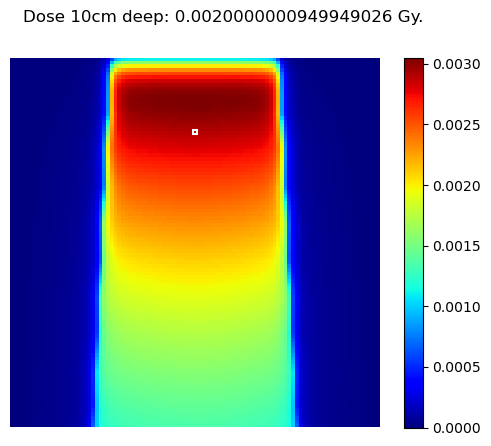

Recommended mean avg. 0.26018762588500977


In [24]:

slice_idx = 84
print(dose.shape)

fig, ax = plt.subplots()
im = ax.imshow(dose[0, 50, :, :].cpu().detach().numpy(), cmap='jet', vmin=np.min(dose.cpu().detach().numpy()), vmax=np.max(dose.cpu().detach().numpy()), interpolation='nearest')


plt.suptitle(f"Dose 10cm deep: {np.round(dose[0, 50, 50, 50].detach().cpu().numpy(), 3)} Gy.")
# Add a rectangle around [25, 64]
rect = patches.Rectangle((50 - 1, 20 - 1), 1, 1, linewidth=1.5, edgecolor='white', facecolor='none')
ax.add_patch(rect)

ax.axis('off')
plt.colorbar(im, ax=ax)
plt.show()
print(f"Recommended mean avg. {machine_config.mean_photon_energy_MeV / dose[0, 50, 50, 50]}")